# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
import os
import sys
from pprint import pprint

# so that mllm_shap can be imported without installing the package
sys.path.insert(0, os.path.abspath("../mllm_shap/src"))

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"
os.environ["LOG_LEVEL"] = "INFO"

In [3]:
import numpy as np
import pandas as pd
import torch

np.random.seed(42)

device = (
    torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
)
print(f"Using device: {device}")

/Users/pawel.pozorski/Desktop/MLLM-Shap/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: mps


In [4]:
from mllm_shap.connectors import LiquidAudio, ModelConfig
from mllm_shap.connectors.enums import ModelHistoryTrackingMode, Role, SystemRolesSetup
from mllm_shap.connectors.filters import ExcludePunctuationTokensFilter
from mllm_shap.shap import Explainer, McShapExplainer
from mllm_shap.shap.embeddings import MeanReducer
from mllm_shap.shap.enums import Mode
from mllm_shap.shap.normalizers import AbsSumNormalizer
from mllm_shap.shap.similarity import TfIdfCosineSimilarity
from mllm_shap.utils.audio import display_audio
from mllm_shap.utils.jupyter import (
    display_shap_colors_df,
    display_shap_colors_df_audio,
    plot_distribution,
)

# Usage

Lets take sample data directly from Hugging Face.

In [5]:
df = pd.read_parquet("hf://datasets/Pawlo77/mllm-shap/single_sentence.parquet")
sample_entry = df.sample(1).iloc[0].to_dict()
del df

pprint(sample_entry)
display_audio(sample_entry["audio__male"][0])

{'audio__female': array([b'\xff\xf3\x84\xc4\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xf3\x84\xc4\x00&2\xd2\x04\x00\xc1\x86\xb9\x1a\x00$j\\\x80\tl\xc40\xe4KZ\xc4\xb6\x1f\x98\xb1R1,\xc7\x0f&Oc\xe1\xe0\x00\x80@\x8cc\x08\x10&L\x992d\xc9\x93L\x81\x04!\x08\x8c\x82i\xff\x0e\x99HY\xe4\xc9\xa7

Define LiquidAudio model (this call loads it up to the memory!).

Create compact explainer that will make initial call and then explain it using Shapley Values approximated using Monte Carlo. Set minimal number of samples for demo purpose, that is only first-order omission ones (where only one token at the time is hidden) and empty sample (if it is not "globally" empty, that is when expandability is not performed on all tokens).

AbsSumNormalizer divides each value by sum of abs shapley values.

In [6]:
model = LiquidAudio(
    device=device, history_tracking_mode=ModelHistoryTrackingMode.AUDIO
)  # track and generate only audio history
shap = McShapExplainer(
    num_samples=-1,
    mode=Mode.CONTEXTUAL,  # use contextual embeddings, default
    # use mean pooling to reduce token embeddings to single embedding per audio, default
    embedding_reducer=MeanReducer(),
    similarity_measure=TfIdfCosineSimilarity(),  # use TF-IDF weighted cosine similarity to compare embeddings
    normalizer=AbsSumNormalizer(),  # use abs sum normalizer to normalize shap values
)
explainer = Explainer(model=model, shap_explainer=shap)

W0505 12:51:34.691000 69848 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Create new chat that treats Assistant messages as system, that is will ignore them for shapley values calculation - they will be feed to each prompt as system messages. This significantly reduces number of requests needed for multi turn expandability, yet might not be possible due to business requirements. 

To further reduce number of calls we exclude punctuation tokens.

In [7]:
chat = model.get_new_chat(
    system_roles_setup=SystemRolesSetup.SYSTEM,  # explain assistant responses as well
    token_filter=ExcludePunctuationTokensFilter(),  # exclude punctuation tokens from shapley values calculation
)

chat.new_turn(Role.USER)
chat.add_text("Who is speaking in the audio?")
chat.add_audio(sample_entry["audio__male"][0])
chat.end_turn()

/Users/pawel.pozorski/Desktop/MLLM-Shap/.venv/lib/python3.12/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 286, 257]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


Let's have a look at chat representation:

In [8]:
pprint(chat.get_conversation())

[[ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM, ..., USER, USER], content='<|im_start|>, user, \n, Who,  is,  speaking,  in,  the,  audio, ?...', shap_values=None),
  ChatEntry(content_type=1, roles=[USER, USER, ..., USER, USER], content='Audio bytes of total length 0', shap_values=None),
  ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM], content='<|im_end|>, \n', shap_values=None)]]


Representation is a list of list of ConversationEntry - so it can be accessed as  chat.get_conversation()[turn_number][message_number].{field}

Let's calculate shapley values for current conversation.

Verbose=False saves memory. Generation kwargs allows to customize model interference - here we limit it to 32 tokens and change text_temperature from default 0.0 to 0.2. 

In [9]:
generation_kwargs = {
    "max_new_tokens": 32,
    "model_config": ModelConfig(text_temperature=0.2),
}

result = explainer(
    chat=chat,
    verbose=True,
    generation_kwargs=generation_kwargs,
    progress_bar=True,  # show progress bar during generation, default
)

2026-05-05 12:51:35,566 - mllm_shap.shap.compact - INFO - Generating full response from the model...
2026-05-05 12:51:37,078 - mllm_shap.shap.base._masks_manager - INFO - Number of tokens for explainability: 42 (up to 4398046511103 additional calls)


Monte Carlo SHAP:   0%|          | 0/43 [00:00<?, ?it/s]

2026-05-05 12:52:29,344 - mllm_shap.shap.base._generate_responses - INFO - Generation stats: processed=43 cache_hits=0 cache_misses=43 skipped_filtered=0 model_elapsed_ms=52052.84
2026-05-05 12:52:29,344 - mllm_shap.shap.base.shap_explainer - INFO - Sampling stats: candidates=44 yielded=43 skipped(full_or_empty)=1 skipped(invalid)=0 skipped(duplicates)=0 elapsed_ms=52207.26


Result has now following fields available:

- full_chat - chat with base response (generated based on whole entry) with set cache and calculated shapley values
- source_chat - original chat feed to the explainer
- history - history of all chats used

In [10]:
explained_chat = result.full_chat

explained_chat_conversation = explained_chat.get_conversation()
pprint(explained_chat_conversation)

[[ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM, ..., USER, USER], content='<|im_start|>, user, \n, Who,  is,  speaking,  in,  the,  audio, ?...', shap_values=[nan, nan, ..., 0.0230852123349905, nan]),
  ChatEntry(content_type=1, roles=[USER, USER, ..., USER, USER], content='Audio bytes of total length 0', shap_values=[-0.008203505538403988, 0.026764044538140297, ..., -0.008203505538403988, 0.024309609085321426]),
  ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM], content='<|im_end|>, \n', shap_values=[nan, nan])],
 [ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM, SYSTEM], content='<|im_start|>, assistant, \n', shap_values=[nan, nan, nan]),
  ChatEntry(content_type=1, roles=[ASSISTANT, ASSISTANT, ..., ASSISTANT, ASSISTANT], content='Audio bytes of total length 77680', shap_values=[nan, nan, ..., nan, nan]),
  ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM], content='<|im_end|>, \n', shap_values=[nan, nan])]]


In [11]:
explained_chat_conversation[1][1].display()

BY: ASSISTANT
AUDIO CONTENT:


Encoding audio tokens in seperation creates weird non-continual audio description.

Model was set to return just text tokens, so chat history has only text tokens. We can see that in the json representation inside ConversationEntry shap_values field is now populated. Nan values indicated that this token wasn't taken into calculation scope. As expected, we have 3 not-nan tokens. Let's see them.

In [12]:
user_entry = explained_chat_conversation[0][0]

display_shap_colors_df(
    pd.DataFrame(
        list(zip(user_entry.content, user_entry.shap_values)),
        columns=["Token", "Shapley Value"],
    )
)

,Token,Shapley Value
0,<|im_start|>,nan
1,user,nan
2,,nan
3,Who,0.021950
4,is,0.023777
5,speaking,0.023223
6,in,0.023649
7,the,0.025252
8,audio,0.023085
9,?,nan


In [13]:
audio_to_explain = explained_chat_conversation[0][1]

display_shap_colors_df_audio(
    pd.DataFrame(
        list(zip(audio_to_explain.content, audio_to_explain.shap_values)),
        columns=["Audio", "Shapley Value"],
    )
)

,Audio,Shapley Value
0,Your browser does not support the audio element.,-0.008204
1,Your browser does not support the audio element.,0.026764
2,Your browser does not support the audio element.,-0.042867
3,Your browser does not support the audio element.,0.026319
4,Your browser does not support the audio element.,0.026653
5,Your browser does not support the audio element.,0.024468
6,Your browser does not support the audio element.,0.020900
7,Your browser does not support the audio element.,-0.042867
8,Your browser does not support the audio element.,0.021525
9,Your browser does not support the audio element.,0.026471


Let's create another turn to see how input significance will change (it is a very dummy audio just for a showcase - now we have text, audio in, audio out and multi turn expandability task):

In [14]:
explained_chat.new_turn(Role.USER)
explained_chat.add_audio(sample_entry["audio__female"][0])
explained_chat.end_turn()

/Users/pawel.pozorski/Desktop/MLLM-Shap/.venv/lib/python3.12/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [1, 313, 257]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


And again, let's explain it:

In [15]:
result = explainer(
    chat=explained_chat, verbose=False, generation_kwargs=generation_kwargs
)

2026-05-05 12:52:30,285 - mllm_shap.shap.compact - INFO - Generating full response from the model...
2026-05-05 12:52:31,847 - mllm_shap.shap.base._masks_manager - INFO - Number of tokens for explainability: 102 (up to 5070602400912917605986812821503 additional calls)
2026-05-05 12:52:31,934 - mllm_shap.shap.base._cache_manager - WARNING - Existing SHAP cache for chat was calculated with external mask, no retrieval will be done.


Monte Carlo SHAP:   0%|          | 0/103 [00:00<?, ?it/s]

2026-05-05 12:54:46,351 - mllm_shap.shap.base._generate_responses - INFO - Generation stats: processed=103 cache_hits=0 cache_misses=103 skipped_filtered=0 model_elapsed_ms=134062.82
2026-05-05 12:54:46,351 - mllm_shap.shap.base.shap_explainer - INFO - Sampling stats: candidates=104 yielded=103 skipped(full_or_empty)=1 skipped(invalid)=0 skipped(duplicates)=0 elapsed_ms=134406.58


In [16]:
explained_chat = result.full_chat

explained_chat_conversation = explained_chat.get_conversation()
pprint(explained_chat_conversation)

[[ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM, ..., USER, USER], content='<|im_start|>, user, \n, Who,  is,  speaking,  in,  the,  audio, ?...', shap_values=[nan, nan, ..., -0.026394056156277657, nan]),
  ChatEntry(content_type=1, roles=[USER, USER, ..., USER, USER], content='Audio bytes of total length 0', shap_values=[0.005830631125718355, -0.054377540946006775, ..., 0.007102272938936949, 0.00948118045926094]),
  ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM], content='<|im_end|>, \n', shap_values=[nan, nan])],
 [ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM, SYSTEM], content='<|im_start|>, assistant, \n', shap_values=[nan, nan, nan]),
  ChatEntry(content_type=1, roles=[ASSISTANT, ASSISTANT, ..., ASSISTANT, ASSISTANT], content='Audio bytes of total length 77680', shap_values=[0.008382798172533512, 0.008991674520075321, ..., 0.009787291288375854, 0.0071417829021811485]),
  ChatEntry(content_type=0, roles=[SYSTEM, SYSTEM], content='<|im_end|>, \n', shap_values=[nan, nan])],
 [C

We can now easily plot their distribution. Don't pay attention to their irrelevance, this example is is very poorly approximated.

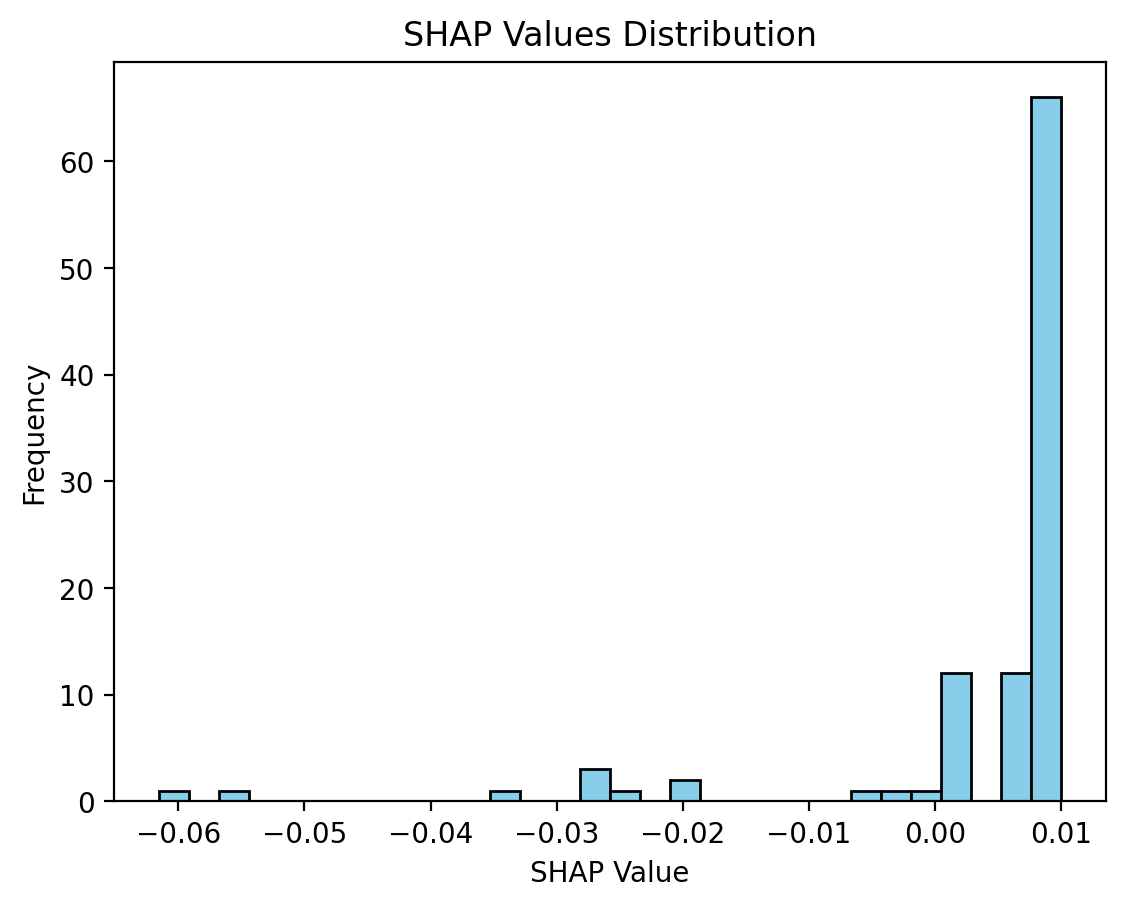

In [17]:
sv = explained_chat.cache.normalized_values

sv = sv[~torch.isnan(sv)]

plot_distribution(sv, bins=30, color="skyblue", edgecolor="black")